In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import os
from datetime import datetime

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [8]:
hiha_genes_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/genes.csv")
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")

In [9]:
print(hiha_genes_df.columns.tolist())

['gene', 'mp', 'score']


In [23]:
print(adata.obs_keys)
print(adata.var_names[:10].tolist())
print(adata.var_names.str.startswith("ENSG").sum())  
print(adata.X.max())  # should be roughly 0–10 if log-normalized; hundreds/thousands if raw

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 633710 × 25987
    obs: 'author', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'gbmap', 'suspension_type', 'stage', 'location', 'sector', 'celltype_original', 'EGFR', 'MET', 'p53', 'TERT', 'ATRX', 'PTEN', 'MGMT', 'chr1p19q', 'PDGFR', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score'
    var: 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_is_filtered', 

In [25]:
n_ensembl_index = adata.var_names.str.startswith("ENSG").sum()
n_ensembl_featurename = adata.var['feature_name'].astype(str).str.startswith("ENSG").sum()
print(f"Ensembl in var_names (index): {n_ensembl_index} / {adata.n_vars}")
print(f"Ensembl in feature_name: {n_ensembl_featurename} / {adata.n_vars}")

Ensembl in var_names (index): 2971 / 25987
Ensembl in feature_name: 3165 / 25987


### 1 - overlap test

In [28]:
overlap_records = []
for mp in hiha_genes_df["mp"].unique():
    mp_genes = hiha_genes_df.loc[hiha_genes_df["mp"] == mp, "gene"].tolist()
    n_total = len(mp_genes)
    n_present = sum(g in adata.var_names for g in mp_genes)
    overlap_records.append({
        "mp": mp,
        "n_total_genes": n_total,
        "n_present_genes": n_present,
        "pct_overlap": n_present / n_total if n_total > 0 else 0.0,
    })

overlap_df = pd.DataFrame(overlap_records).sort_values("pct_overlap")
print(overlap_df.to_string(index=False))

 mp  n_total_genes  n_present_genes  pct_overlap
MP4             57               54     0.947368
MP8            372              364     0.978495
MP7             77               76     0.987013
MP1             74               74     1.000000
MP3             15               15     1.000000
MP2             14               14     1.000000
MP6             18               18     1.000000
MP5             38               38     1.000000


In [30]:
print(adata.var_names.duplicated().sum())

0


#### score onto GBmap

In [31]:
min_overlap = 0.5  # not really needed given your results, but keep as a safety net
mps_to_score = overlap_df.loc[overlap_df["pct_overlap"] >= min_overlap, "mp"].tolist()

for mp in mps_to_score:
    mp_df = hiha_genes_df[hiha_genes_df["mp"] == mp]
    gene_weights = dict(zip(mp_df["gene"], mp_df["score"]))

    genes_present = [g for g in gene_weights if g in adata.var_names]
    weights = np.array([gene_weights[g] for g in genes_present])
    gene_idx = [adata.var_names.get_loc(g) for g in genes_present]

    X_sub = adata[:, gene_idx].X
    if sp.issparse(X_sub):
        X_sub = X_sub.toarray()

    weighted_score = (X_sub * weights).sum(axis=1) / weights.sum()
    adata.obs[f"HIHA_{mp}_score"] = np.asarray(weighted_score).flatten()

print(f"Scored {len(mps_to_score)} HIHA MPs onto GBMap.")

Scored 8 HIHA MPs onto GBMap.


In [33]:
score_cols = [f"HIHA_{mp}_score" for mp in mps_to_score]
print(adata.obs[score_cols].describe())

       HIHA_MP4_score  HIHA_MP8_score  HIHA_MP7_score  HIHA_MP1_score  \
count   633710.000000   633710.000000   633710.000000   633710.000000   
mean         0.047142        0.274494        0.044422        0.370172   
std          0.039315        0.073583        0.086747        0.230799   
min          0.000000        0.010077        0.000000        0.000000   
25%          0.019458        0.226158        0.010185        0.189317   
50%          0.042481        0.276771        0.023887        0.382197   
75%          0.066317        0.326669        0.043776        0.523515   
max          2.417406        0.623731        1.171842        1.567865   

       HIHA_MP3_score  HIHA_MP2_score  HIHA_MP6_score  HIHA_MP5_score  
count   633710.000000   633710.000000   633710.000000   633710.000000  
mean         0.186727        0.031715        0.133620        0.101493  
std          0.291334        0.095131        0.258116        0.080670  
min          0.000000        0.000000        0.000000 

### UMAP grid

In [36]:
import re
import matplotlib.pyplot as plt

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
MP_PALETTE_HIHA_ALT = {
    "MP1": "#0caece",  # 
    "MP2": "#946da1",  # 
    "MP3": "#90e0ef",  # 
    "MP4": "#00c39f",  # 
    "MP5": "#655fdc",  # 
    "MP6": "#4cd276",  # 
    "MP7": "#6B157A",  # 
    "MP8": "#939393",  # 
}

[2026-08-28 13:14:05] 
Available MPs: 8
[2026-08-28 13:14:05] Available: ['HIHA_MP4_score', 'HIHA_MP8_score', 'HIHA_MP7_score', 'HIHA_MP1_score', 'HIHA_MP3_score', 'HIHA_MP2_score', 'HIHA_MP6_score', 'HIHA_MP5_score']
[2026-08-28 13:14:05] Plotting UMAPs
[2026-08-28 13:14:06] Plotted HIHA_MP1_score
[2026-08-28 13:14:07] Plotted HIHA_MP2_score
[2026-08-28 13:14:08] Plotted HIHA_MP3_score
[2026-08-28 13:14:09] Plotted HIHA_MP4_score
[2026-08-28 13:14:10] Plotted HIHA_MP5_score
[2026-08-28 13:14:11] Plotted HIHA_MP6_score
[2026-08-28 13:14:12] Plotted HIHA_MP7_score
[2026-08-28 13:14:13] Plotted HIHA_MP8_score


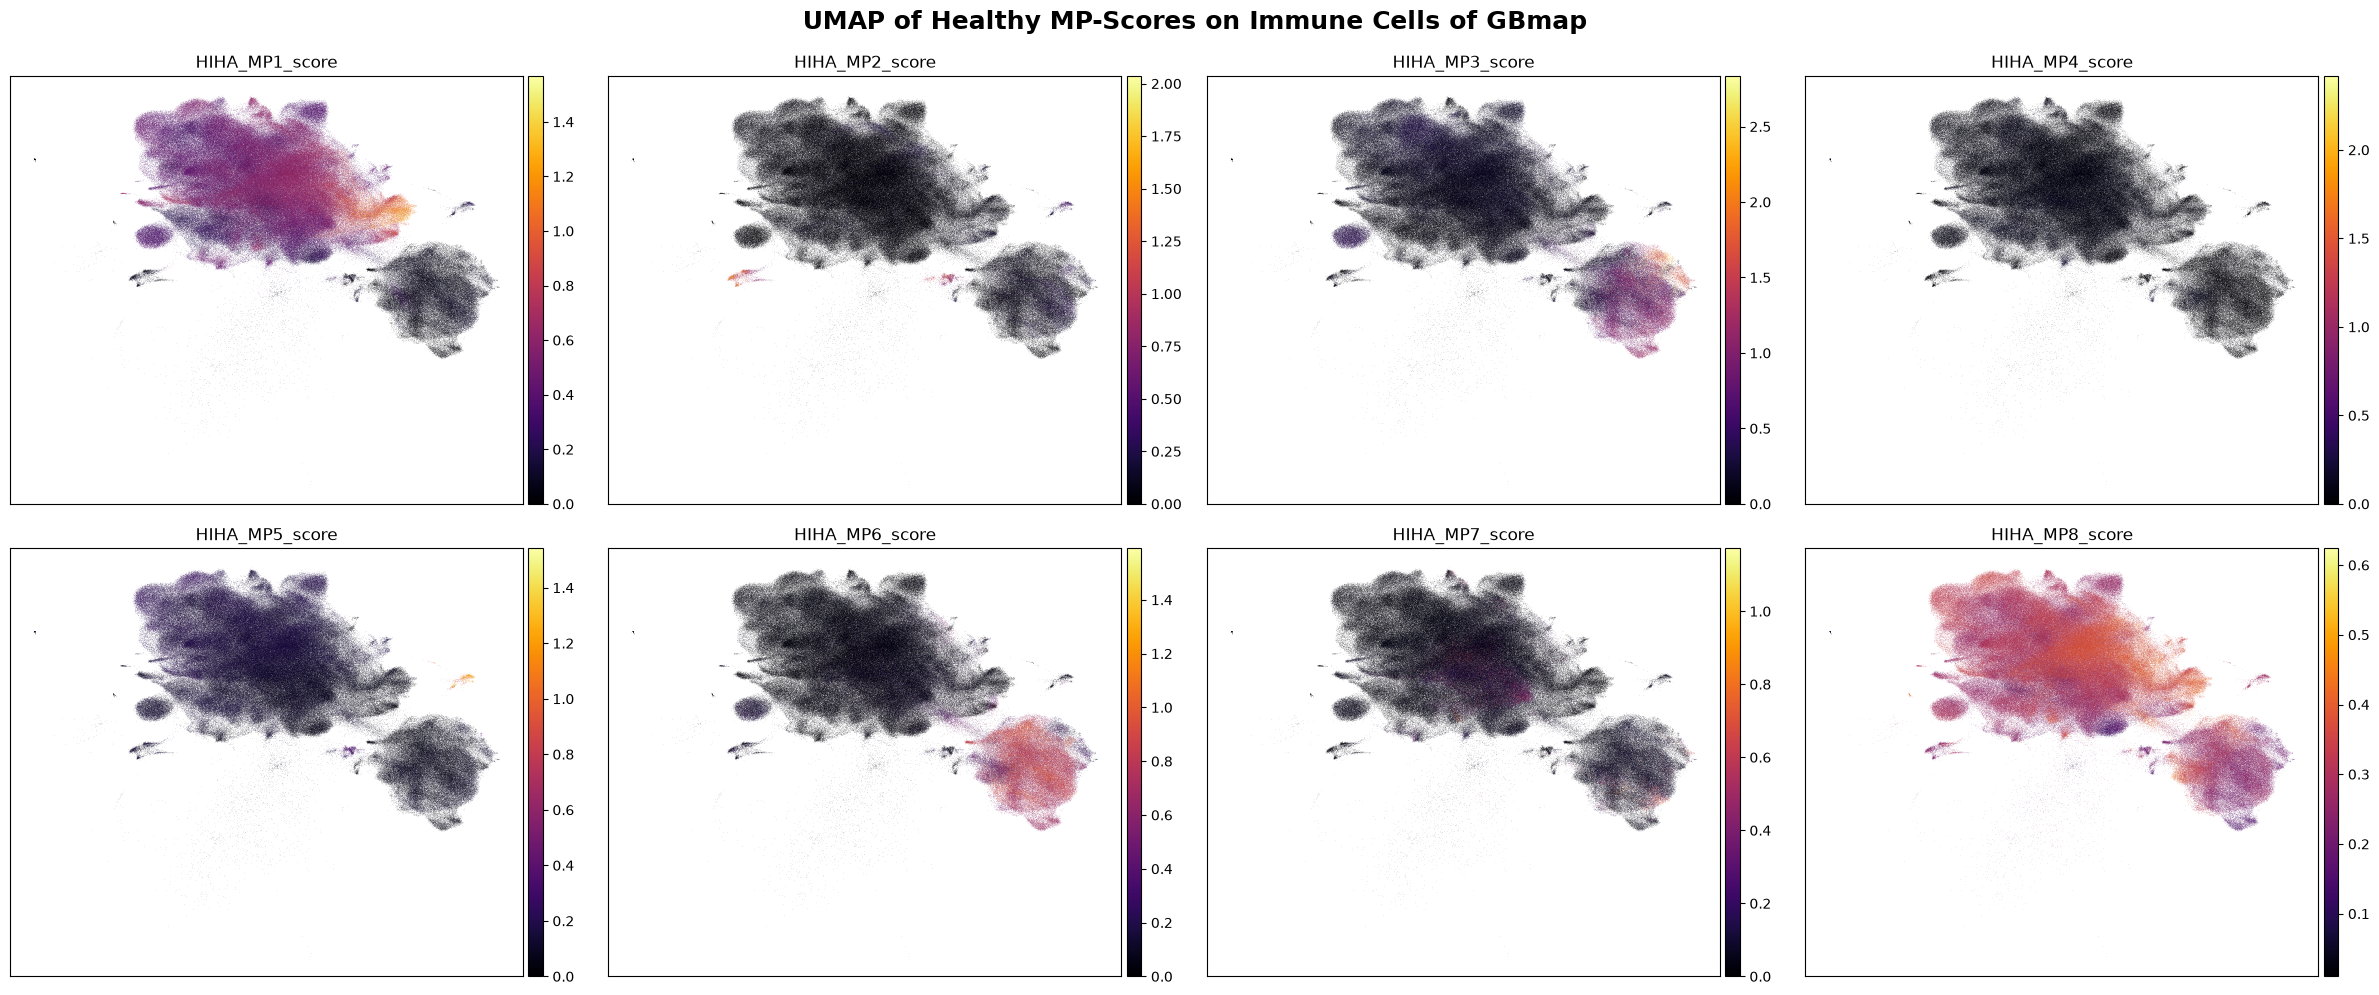

[2026-08-28 13:15:00] PDF saved


In [38]:
def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0

available_mps = [mp for mp in score_cols if mp in adata.obs.columns and adata.obs[mp].notna().any()]
checkpoint(f"\nAvailable MPs: {len(available_mps)}")
checkpoint(f"Available: {available_mps}")

ALL_MPS = sorted(available_mps, key=mp_sort_key)


checkpoint("Plotting UMAPs")
n_cols = 4  
n_rows = -(-len(ALL_MPS) // n_cols)  # ceiling division = 2


fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))  # ← figsize anpassen!
axes = axes.flatten()

fig.suptitle("UMAP of Healthy MP-Scores on Immune Cells of GBmap", fontsize=18, fontweight='bold', y=0.99)

for i, mp in enumerate(ALL_MPS):
    if mp in adata.obs.columns:
        # vmin/vmax per MP
        mp_vmin = adata.obs[mp].min()
        mp_vmax = adata.obs[mp].max()
        sc.pl.umap(
            adata, 
            color=mp, 
            color_map="inferno", 
            show=False, 
            ax=axes[i], 
            title=mp.replace("_hiha_score", ""),
            vmin=mp_vmin,
            vmax=mp_vmax
        )
        axes[i].set_rasterized(True)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_06b_umap_grid_healthy_score_on_GBmap.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")